In [60]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


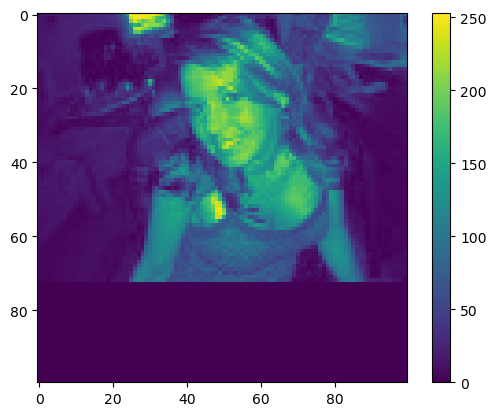

In [64]:
def convert_csv_to_array(picture):
    new_picture = []
    for i in picture:
        new_picture.append(int(i))
    new_picture = np.array(new_picture)
    picture = np.concatenate((new_picture , np.zeros(10000 - new_picture.shape[0])) ).reshape(100,100)
    return picture

abalone_train = pd.read_csv("SmallData.csv")

picture = np.array(abalone_train.iloc[0])[0].split(",")

new_picture = convert_csv_to_array(picture)

plt.figure()
plt.imshow(new_picture)
plt.colorbar()
plt.grid(False)
plt.show()

(90, 1)
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89


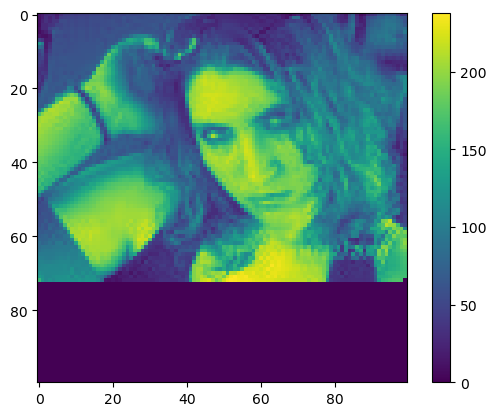

In [87]:
print(abalone_train.shape)

female_pictures = []

for i,j in enumerate(range(abalone_train.shape[0])):
    print(i)
    picture = np.array(abalone_train.iloc[i])[0].split(",")
    conv_picture = convert_csv_to_array(picture)
    female_pictures.append(conv_picture)

female_pictures = np.array(female_pictures)

#plt.figure()
#plt.imshow(female_pictures[1])
#plt.colorbar()
#plt.grid(False)
#plt.show()

In [128]:
import os             
all_files = os.listdir("female/Rating")

data_labels = []

for filename in all_files:
    with open("female/Rating/"+filename, "rt") as fd:
        first_line = fd.readline()
        data_labels.append(float(first_line))
        
data_labels = np.array(data_labels)


In [151]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

train_data = female_pictures[0:70] / 255.0
train_labels = data_labels[0:70] 

test_data = female_pictures[70:90] / 255.0
test_labels = data_labels[70:90] 

train_data = train_data[..., tf.newaxis]
test_data = test_data[..., tf.newaxis]

In [160]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))


model.summary()

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, epochs=50, 
                    validation_data=(test_data, test_labels))


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,361,418 (16.64 MB)

 Trainable params: 4,361,418 (16.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.0221 - loss: 2.0837 - val_accuracy: 0.0500 - val_loss: 1.4638
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.0000e+00 - loss: 1.5162 - val_accuracy: 0.0500 - val_loss: 1.5128
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.0481 - loss: 1.4129 - val_accuracy: 0.0500 - val_loss: 1.3934
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.0754 - loss: 1.2707 - val_accuracy: 0.0500 - val_loss: 1.3395
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.0598 - loss: 1.0904 - val_accuracy: 0.0500 - val_loss: 1.3512
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.0364 - loss: 1.1214 - val_accuracy: 0.0500 - val_loss: 1.3864
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.0787 - loss: 0.9687 - val_accuracy: 0.0500 - val_loss: 1.4691
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.0865 - loss: 0.9014 - val_accuracy: 0.0500 - val_l

1/1 - 0s - 41ms/step - accuracy: 0.0500 - loss: 3.8953
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([[ -7.362, -20.61 ,  -6.105, -15.553, -13.332,  -0.308,   1.367,
         15.829,  19.116,  20.22 ]], dtype=float32)

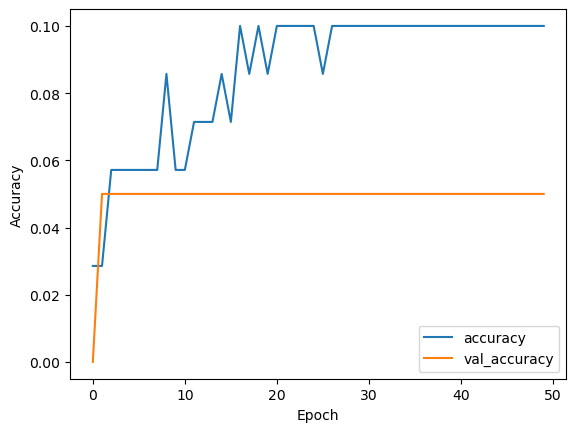

In [153]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_data,  test_labels, verbose=2)



In [162]:
model = tf.keras.Sequential([model, 
                                         tf.keras.layers.Softmax()])
print(model.predict(test_data[15:16]))
test_labels[15:16]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[[0.087 0.087 0.087 0.087 0.087 0.087 0.087 0.102 0.089 0.199]]


array([9.3])